In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### Function Defining

In [21]:
def plot_eda_vertical(
    df,
    variables,
    kind="box",
    logy=True,
    title_prefix="",
    save_path=None,      # <-- ΝΕΟ
    dpi=300              # <-- ΝΕΟ (για publication quality)
):
    n = len(variables)
    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=(10, 4*n),
        sharex=False
    )

    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):

        if kind == "box":
            sns.boxplot(data=df, x="injury", y=var, ax=ax)

        elif kind == "violin":
            sns.violinplot(data=df, x="injury", y=var, inner="quartile", ax=ax)

        elif kind == "kde":
            sns.kdeplot(data=df, x=var, hue="injury", common_norm=False, ax=ax)

        if logy and kind != "kde":
            ax.set_yscale("log")

        ax.set_title(f"{title_prefix}{var}", fontsize=14)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # 🔥 SAVE
    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

### Loading Datasets

In [22]:
master_session_2020 = pd.read_csv('D:/PhD EMP/2020/master_session.csv').drop("Unnamed: 0", axis=1)

In [23]:
print("Athlete-sessions:", len(master_session_2020))
print("Athletes:", master_session_2020["player_name"].nunique())
print("Positive athlete-sessions:", master_session_2020["injury"].sum())

print(
    "Positive athletes:",
    master_session_2020.loc[
        master_session_2020["injury"] == 1,
        "player_name"
    ].nunique()
)

print(
    "Positive prevalence:",
    master_session_2020["injury"].mean()
)

Athlete-sessions: 3743
Athletes: 48
Positive athlete-sessions: 22
Positive athletes: 5
Positive prevalence: 0.005877638258081752


### Data Inspection

In [4]:
master_session_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3743 entries, 0 to 3742
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   player_name         3743 non-null   object 
 1   team                3743 non-null   object 
 2   session_id          3743 non-null   object 
 3   total_minutes       3743 non-null   int64  
 4   speed_mean_sess     3743 non-null   float64
 5   speed_sum_sess      3743 non-null   float64
 6   hr_mean_sess        3743 non-null   float64
 7   hr_sum_sess         3743 non-null   float64
 8   inst_acc_mean_sess  3743 non-null   float64
 9   inst_acc_sum_sess   3743 non-null   float64
 10  hacc_mean_sess      3743 non-null   float64
 11  hacc_sum_sess       3743 non-null   float64
 12  accl_x_mean_sess    3743 non-null   float64
 13  accl_x_sum_sess     3743 non-null   float64
 14  accl_y_mean_sess    3743 non-null   float64
 15  accl_y_sum_sess     3743 non-null   float64
 16  accl_z

### Data Inspection

In [5]:
master_session_2020.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3743 entries, 0 to 3742
Data columns (total 46 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   player_name         3743 non-null   object 
 1   team                3743 non-null   object 
 2   session_id          3743 non-null   object 
 3   total_minutes       3743 non-null   int64  
 4   speed_mean_sess     3743 non-null   float64
 5   speed_sum_sess      3743 non-null   float64
 6   hr_mean_sess        3743 non-null   float64
 7   hr_sum_sess         3743 non-null   float64
 8   inst_acc_mean_sess  3743 non-null   float64
 9   inst_acc_sum_sess   3743 non-null   float64
 10  hacc_mean_sess      3743 non-null   float64
 11  hacc_sum_sess       3743 non-null   float64
 12  accl_x_mean_sess    3743 non-null   float64
 13  accl_x_sum_sess     3743 non-null   float64
 14  accl_y_mean_sess    3743 non-null   float64
 15  accl_y_sum_sess     3743 non-null   float64
 16  accl_z

### Is there signal in the data

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", context="talk")

In [7]:
MECHANICAL_VARS = [
    "total_minutes",
    "speed_mean_sess","speed_sum_sess",
    "hr_mean_sess","hr_sum_sess",
    "inst_acc_mean_sess","inst_acc_sum_sess",
    "hacc_mean_sess","hacc_sum_sess",
    "accl_x_mean_sess","accl_x_sum_sess",
    "accl_y_mean_sess","accl_y_sum_sess",
    "accl_z_mean_sess","accl_z_sum_sess",
    "gyro_x_mean_sess","gyro_x_sum_sess",
    "gyro_y_mean_sess","gyro_y_sum_sess",
    "gyro_z_mean_sess","gyro_z_sum_sess",
]

SUBJECTIVE_VARS = [
    "srpe_sum","duration_sum","rpe_mean","rpe_max","n_sessions",
    "atl","ctl28","ctl42","daily_load","monotony","strain","weekly_load","acwr",
    "sleep_duration","sleep_quality",
    "fatigue","mood","readiness","soreness","stress"
]

In [8]:
# Distribution of recorded injury-status labels
master_session_2020['injury'].value_counts()             

0    3721
1      22
Name: injury, dtype: int64

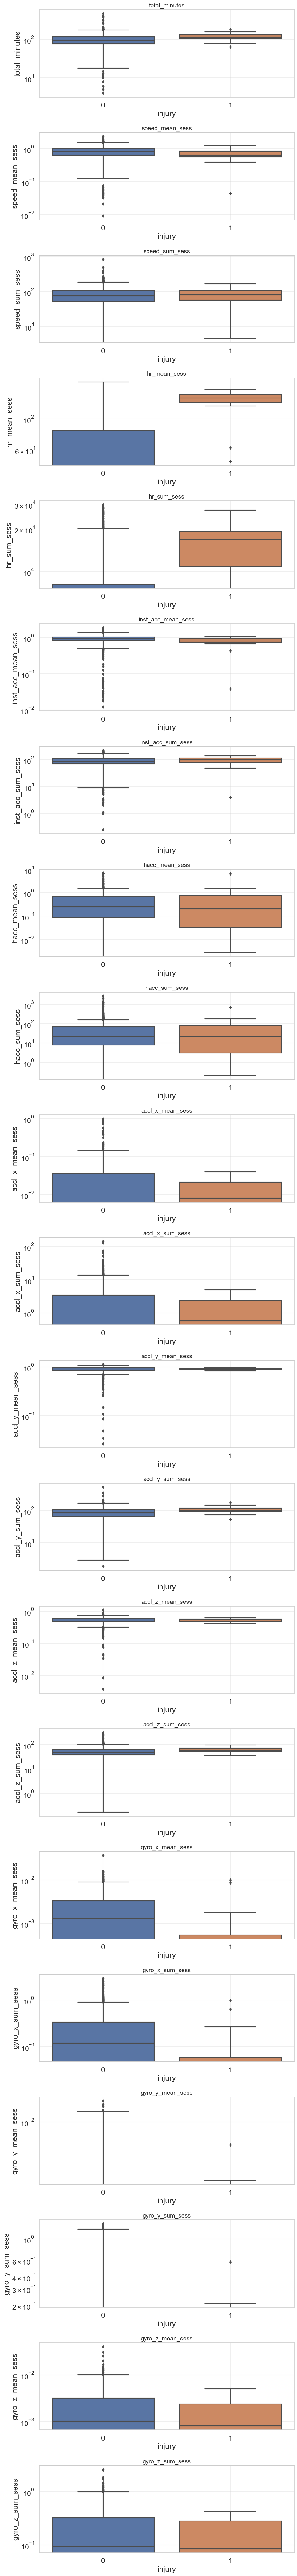

In [9]:
plot_eda_vertical(df=master_session_2020, variables = MECHANICAL_VARS,
                  save_path="eda_plots/mechanical_sum.png"
                 )

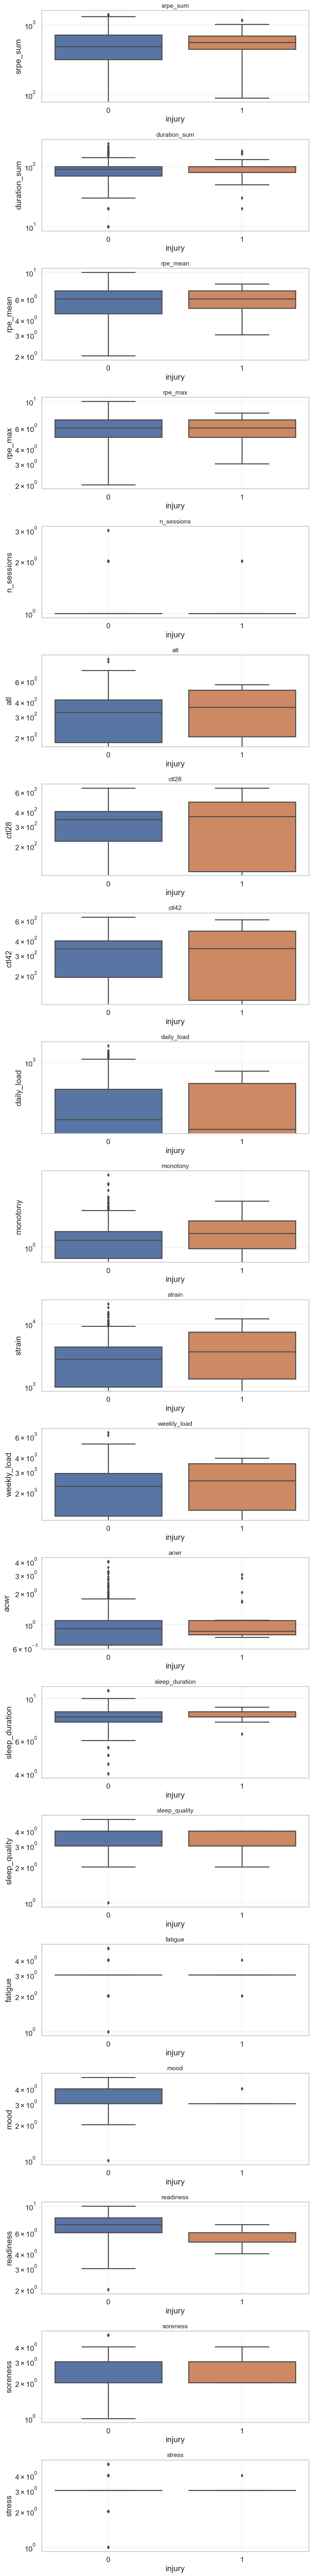

In [10]:
plot_eda_vertical(df=master_session_2020, variables = SUBJECTIVE_VARS,
                  save_path="eda_plots/subjective_sum.png"
                 )

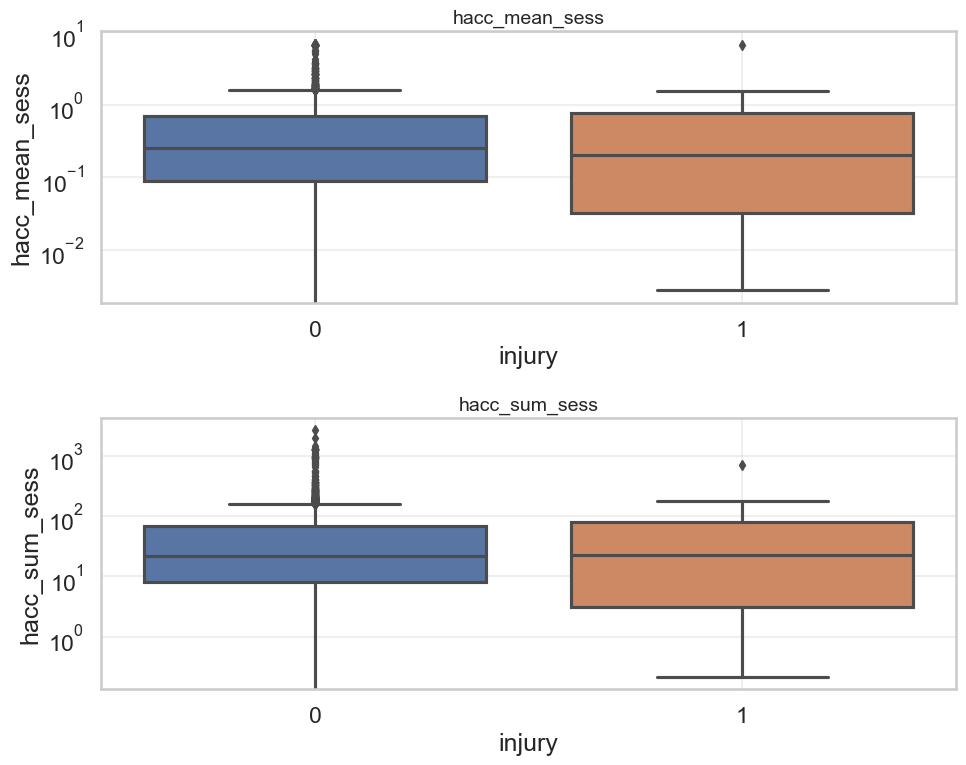

In [11]:
MECHANICAL_VARS = [
    "hacc_mean_sess","hacc_sum_sess",
]


plot_eda_vertical(df=master_session_2020, variables = MECHANICAL_VARS,
                  save_path="eda_plots/hacc_plot.png"
                 )

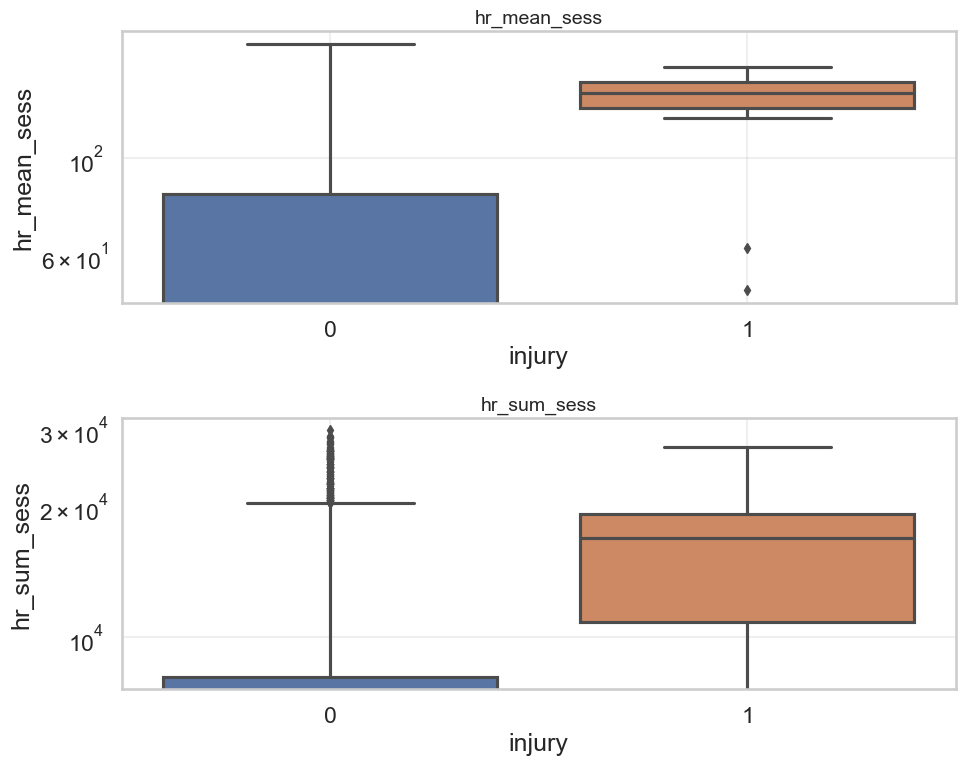

In [12]:
MECHANICAL_VARS = [
    "hr_mean_sess","hr_sum_sess",
]


plot_eda_vertical(df=master_session_2020, variables = MECHANICAL_VARS,
                  save_path="eda_plots/heart_rate.png"
                 )

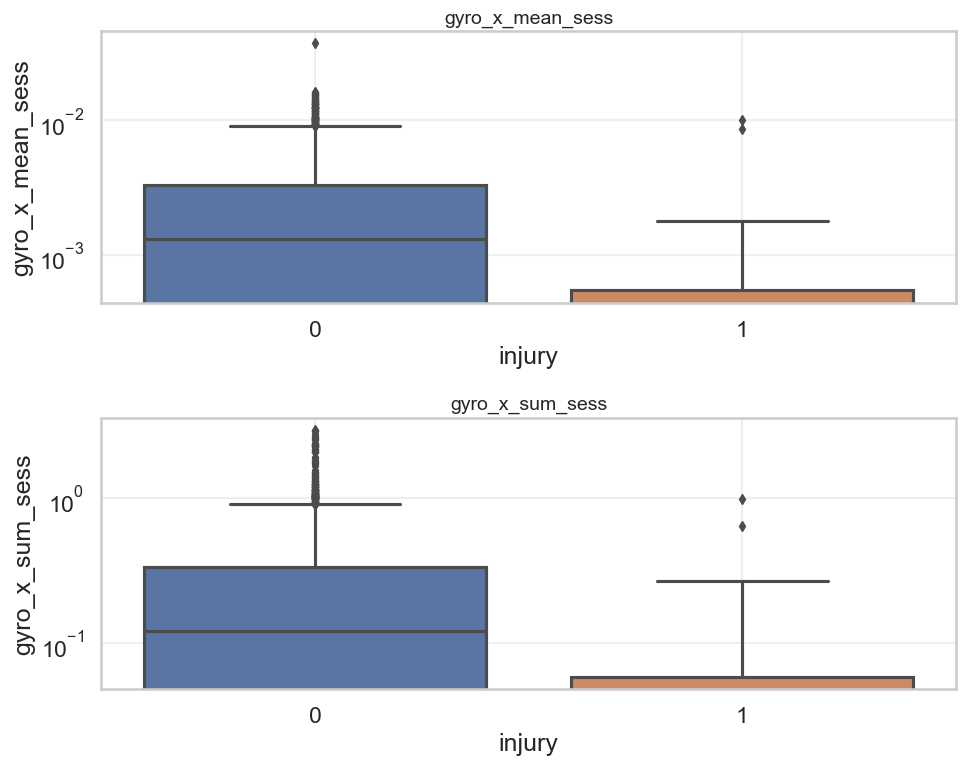

In [13]:
MECHANICAL_VARS = [
    "gyro_x_mean_sess","gyro_x_sum_sess",
]


plot_eda_vertical(df=master_session_2020, variables = MECHANICAL_VARS,
                  save_path="eda_plots/gyroscopic.png"
                 )

In [14]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_eda_vertical(
    df,
    variables,
    kind="box",
    logy=True,
    title_prefix="",
    save_path=None,
    dpi=300,
    figsize_per_plot=4,
    clip_outliers=False,
    lower_pct=1,
    upper_pct=99
):
    n = len(variables)
    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=(10, max(figsize_per_plot * n, 4)),
        sharex=False
    )

    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):
        if var not in df.columns:
            ax.set_visible(False)
            continue

        plot_df = df[["injury", var]].copy()
        plot_df = plot_df.dropna()

        if plot_df.empty:
            ax.set_title(f"{title_prefix}{var} (no data)", fontsize=14)
            ax.set_visible(False)
            continue

        # Log scale cannot handle <= 0
        if logy and kind != "kde":
            plot_df = plot_df[plot_df[var] > 0]

        if plot_df.empty:
            ax.set_title(f"{title_prefix}{var} (no positive values for log scale)", fontsize=14)
            ax.set_visible(False)
            continue

        if kind == "box":
            sns.boxplot(data=plot_df, x="injury", y=var, ax=ax)

        elif kind == "violin":
            sns.violinplot(data=plot_df, x="injury", y=var, inner="quartile", ax=ax)

        elif kind == "kde":
            sns.kdeplot(data=plot_df, x=var, hue="injury", common_norm=False, ax=ax)

        else:
            raise ValueError("kind must be one of: 'box', 'violin', 'kde'")

        if logy and kind != "kde":
            ax.set_yscale("log")

        # Optional clipping to make the box visible when extreme outliers exist
        if clip_outliers and kind != "kde":
            y = plot_df[var].values
            y_low = np.percentile(y, lower_pct)
            y_high = np.percentile(y, upper_pct)

            if logy:
                y_low = max(y_low, np.min(y[y > 0]))

            if y_low < y_high:
                ax.set_ylim(y_low, y_high)

        ax.set_title(f"{title_prefix}{var}", fontsize=14)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

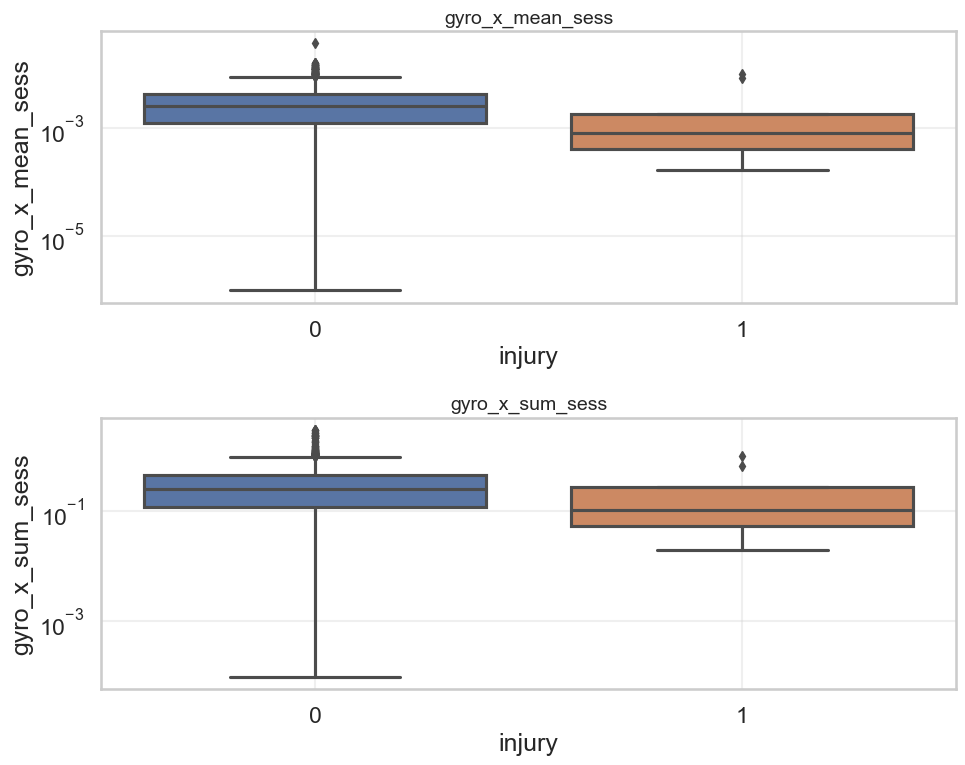

In [15]:
MECHANICAL_VARS = [
    "gyro_x_mean_sess","gyro_x_sum_sess",
]

plot_eda_vertical(master_session_2020, MECHANICAL_VARS, kind="box", logy=True,
                 save_path="eda_plots/gyroscopic.png")

In [16]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_eda_vertical(
    df,
    variables,
    kind="box",
    logy=True,
    title_prefix="",
    save_path=None,
    dpi=300,
    showfliers=False
):
    n = len(variables)
    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=(10, 4 * n),
        sharex=False
    )

    if n == 1:
        axes = [axes]

    for ax, var in zip(axes, variables):
        plot_df = df[["injury", var]].copy().dropna()

        if plot_df.empty:
            ax.set_title(f"{title_prefix}{var} (no data)", fontsize=14)
            ax.grid(True, alpha=0.3)
            continue

        if logy and kind != "kde":
            plot_df = plot_df[plot_df[var] > 0]

        if plot_df.empty:
            ax.set_title(f"{title_prefix}{var} (no positive values)", fontsize=14)
            ax.grid(True, alpha=0.3)
            continue

        if kind == "box":
            sns.boxplot(
                data=plot_df,
                x="injury",
                y=var,
                ax=ax,
                showfliers=showfliers
            )

        elif kind == "violin":
            sns.violinplot(
                data=plot_df,
                x="injury",
                y=var,
                inner="quartile",
                ax=ax
            )

        elif kind == "kde":
            sns.kdeplot(
                data=plot_df,
                x=var,
                hue="injury",
                common_norm=False,
                ax=ax
            )

        else:
            raise ValueError("kind must be one of: 'box', 'violin', 'kde'")

        if logy and kind != "kde":
            ax.set_yscale("log")

        ax.set_title(f"{title_prefix}{var}", fontsize=14)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=dpi, bbox_inches="tight")

    plt.show()

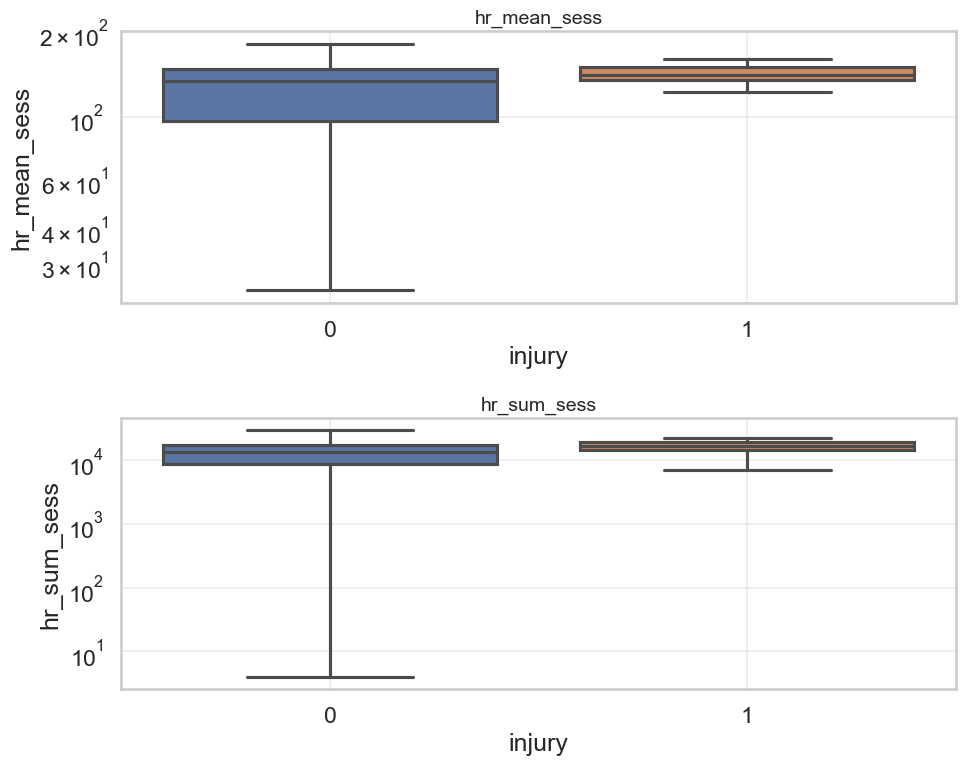

In [17]:
MECHANICAL_VARS = [
    "hr_mean_sess","hr_sum_sess",
]


plot_eda_vertical(df=master_session_2020, variables = MECHANICAL_VARS,
                  save_path="eda_plots/heart_rate.png",
                  showfliers=False
                 )

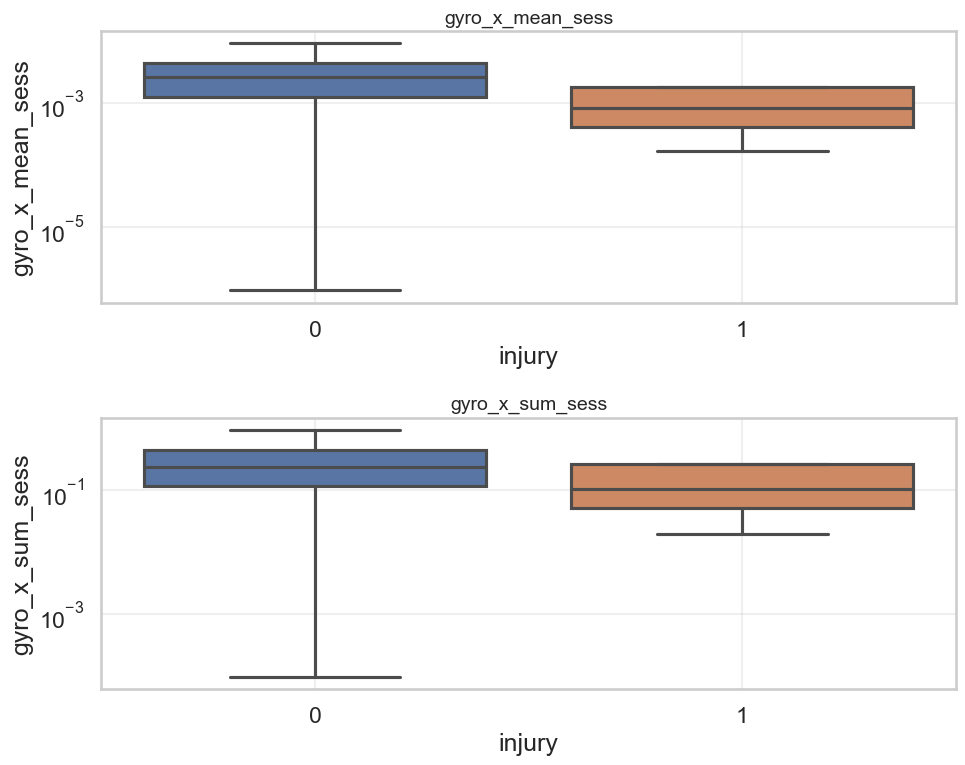

In [18]:
MECHANICAL_VARS = [
    "gyro_x_mean_sess","gyro_x_sum_sess",
]


plot_eda_vertical(df=master_session_2020, variables = MECHANICAL_VARS,
                  save_path="eda_plots/gyroscopic.png"
                 )

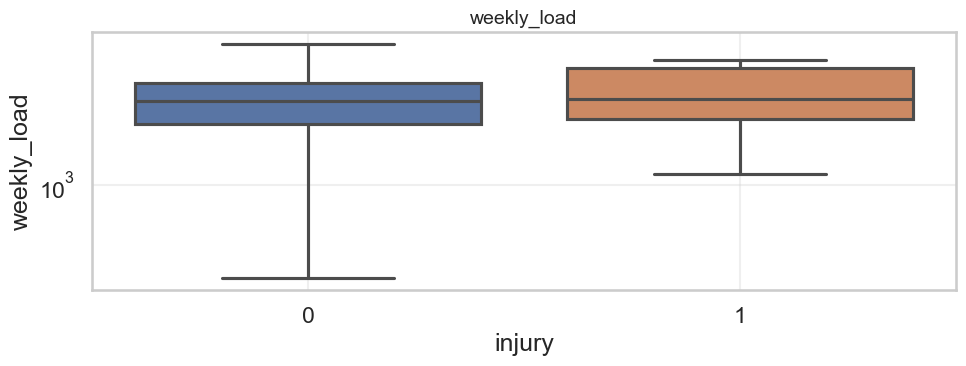

In [19]:
subjective = [
    "weekly_load"
]


plot_eda_vertical(df=master_session_2020, variables = subjective,
                  save_path="eda_plots/weekly_load.png"
                 )

### FINAL NOTES, FINDINGS, JUSTIFICATIONS

### FINAL NOTES, FINDINGS, JUSTIFICATIONS

The session-level EDA is used exclusively as a descriptive analysis of the
study cohort. It examines whether distributions of mechanical, workload,
sleep, and wellness variables differ between athlete-sessions with and
without a recorded injury status.

Observed differences or distributional shifts are treated as exploratory
associations only. They do not establish injury onset, causality, temporal
precedence, or prospective predictive value.

Because the injury records do not provide a verified within-session injury
onset time, the positive class represents athlete-sessions occurring on days
with a recorded injury status rather than confirmed sessions in which a new
injury occurred.

Session-level aggregation also removes within-session temporal information.
Consequently, subsequent minute-level analyses investigate whether
discriminative information associated with recorded injury status emerges
progressively as within-session observations accumulate. These analyses are
therefore interpreted as progressive injury-status discrimination and not
as prediction of future injury onset.